<a href="https://colab.research.google.com/github/balajiduddukuri/Langchain_practice/blob/Ultimate-Content-Repurposer/SDD_fullcycle_langchain.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##SSD LOOP:

idea → spec → clarifications → plan/tasks → implement (full_agent) → test → review_gate → (done or back to implement)

In [68]:
!pip install -q --upgrade langgraph langchain langchain-openai langchain_community openai langchain-core chromadb faiss-cpu pypdf tiktoken docarray

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 169.8/169.8 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 112.7/112.7 kB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 508.3/508.3 kB 24.3 MB/s eta 0:00:00


In [2]:
pip show langchain

Name: langchain
Version: 1.2.14
Summary: Building applications with LLMs through composability
Home-page: https://docs.langchain.com/
Author: 
Author-email: 
License: MIT
Location: /usr/local/lib/python3.12/dist-packages
Requires: langchain-core, langgraph, pydantic
Required-by: 


In [3]:
import os
from google.colab import userdata

os.environ['OPENAI_API_KEY'] = userdata.get("api_key")
print("OPENAI API key is loaded successfully")

OPENAI API key is loaded successfully


In [4]:
from typing import TypedDict, List, Dict

class SDDState(TypedDict):
    idea: str
    spec_md: str
    clarifications: List[str]
    clarification_answers: List[str]
    impl_plan_md: str
    tasks_md: str
    dev_tasks: List[str]
    code_changes: Dict[str, str]
    test_code_py: str             # generated test code (Python)
    test_results: List[str]       # textual results per test
    status: str                   # "testing" | "needs_fix" | "done"

# 2. The specify_node implementation

In [9]:
from langchain_openai import ChatOpenAI

llm_spec = ChatOpenAI(model = "gpt-4o-mini", temperature = 0.7)

def specify_node(state: SDDState) -> dict:
    """Generate an opinionated spec_md from a high-level idea."""
    idea = state["idea"]

    system_msg = (
        "You are a senior product engineer practicing Spec-Driven Development.\n"
        "Given a high-level idea, produce a SPECIFICATION in Markdown.\n"
        "The spec is for an AI-assisted implementation later, so it must be:\n"
        "- concrete, testable, and unambiguous\n"
        "- focused on what to build, not how to implement.\n"
        "Follow this structure:\n"
        "1. Overview\n"
        "2. User Personas\n"
        "3. User Stories (with Gherkin-style Acceptance Criteria per story)\n"
        "4. Functional Requirements\n"
        "5. Non-Functional Requirements\n"
        "6. Edge Cases & Constraints\n"
        "7. Open Questions\n"
        "Use Given/When/Then format for acceptance criteria."
    )

    user_msg = (
        f"High-level idea:\n"
        f"{idea}\n\n"
        f"Context: This is the HOME SCREEN for a web e-commerce product.\n"
        f"Assume a generic multi-category store (electronics, fashion, home, etc.).\n"
        f"Target device: responsive web (mobile, tablet, desktop).\n"
        f"Generate the full spec in Markdown now."
    )

    response = llm_spec.invoke(
        [
            {"role": "system", "content": system_msg},
            {"role": "user",   "content": user_msg},
        ]
    )

    spec_md = response.content.strip()
    return {"spec_md": spec_md}

Clarification node (question generation)
This node just finds gaps and generates questions; we’ll do merging in a follow‑up call.

In [10]:
from langchain_openai import ChatOpenAI

llm_clarify = ChatOpenAI(model = "gpt-4o-mini", temperature = 0.7)

def clarify_node(state: SDDState) -> dict:
    """
    Look at spec_md, compare against an SDD checklist (scope, data model, UX,
    NFRs, integrations, edge cases, completion signals), and ask 3–5 questions.
    """
    spec_md = state["spec_md"]

    system_msg = (
        "You are an assistant practicing Spec-Driven Development clarification, "
        "similar to GitHub Spec Kit /clarify.\n"
        "Your job: read the spec.md and find the 3–5 MOST IMPORTANT ambiguities.\n"
        "Focus on:\n"
        "- Functional scope & what is explicitly IN / OUT\n"
        "- Domain & data model (entities, attributes, relationships)\n"
        "- UX flows & navigation\n"
        "- Non-functional requirements (performance, security, accessibility)\n"
        "- External integrations (APIs, auth, payments, tracking)\n"
        "- Edge cases & failure modes\n"
        "- Clear completion signals / success criteria\n"
        "Output ONLY a numbered list of questions, each on its own line.\n"
        "Questions must be concrete and answerable briefly."
    )

    user_msg = (
        "Here is the current spec.md for an e-commerce HOME SCREEN.\n\n"
        "SPEC START\n"
        f"{spec_md}\n"
        "SPEC END\n\n"
        "Identify the top 3–5 missing or ambiguous points and ask clarification questions."
    )

    response = llm_clarify.invoke(
        [
            {"role": "system", "content": system_msg},
            {"role": "user",   "content": user_msg},
        ]
    )

    questions_raw = response.content.strip()
    # keep as a single string or split into list
    questions = [q.strip() for q in questions_raw.split("\n") if q.strip()]

    return {
        "clarifications": questions,
        # we don't change spec yet; we wait for your answers
    }

In [13]:
from langchain_openai import ChatOpenAI

llm_plan = ChatOpenAI(model = "gpt-4o-mini", temperature = 0.7)

def plan_node(state: SDDState) -> dict:
    """
    Generate an implementation plan and a task checklist from spec_md
    for an e-commerce HOME SCREEN, grouped into BA/DEV/QA/RELEASE phases.
    """
    spec_md = state["spec_md"]

    system_msg = (
        "You are a senior tech lead practicing Spec-Driven Development.\n"
        "Given a feature spec, you produce two Markdown artifacts:\n"
        "1) plan.md – implementation plan\n"
        "2) tasks.md – detailed checklist of tasks derived from the plan.\n\n"
        "Follow this methodology (inspired by spec-first workflows):\n"
        "- Analyze the spec: user stories, FR, NFR, edge cases.\n"
        "- Create a concise plan with phases (BA, DEV, QA, RELEASE).\n"
        "- Break the plan into small, independent tasks that an AI agent can execute.\n"
        "- Each task MUST be:\n"
        "  - implementable and testable in isolation\n"
        "  - mapped to at least one user story / requirement.\n"
        "Use Markdown headings for structure."
    )

    user_msg = (
        "SPECIFICATION (spec.md) FOR: E-commerce HOME SCREEN\n"
        "-----------------------------------------------\n"
        f"{spec_md}\n"
        "-----------------------------------------------\n\n"
        "Produce TWO SECTIONS in your answer:\n"
        "=== PLAN_MD ===\n"
        "- A Markdown plan grouped by phases: BA, DEV, QA, RELEASE.\n"
        "- For each phase, list numbered items with short descriptions.\n\n"
        "=== TASKS_MD ===\n"
        "- A Markdown checklist grouped by the same phases.\n"
        "- Each task line must be in the format:\n"
        "  - [ ] TASK_ID: short description (links: US-x, FR-y)\n"
        "- TASK_ID format: BA-1, BA-2, DEV-1, QA-1, REL-1, etc.\n"
        "- Keep each task small enough for a single agent run."
    )

    response = llm_plan.invoke(
        [
            {"role": "system", "content": system_msg},
            {"role": "user",   "content": user_msg},
        ]
    )

    full = response.content.strip()

    # Simple split into plan_md and tasks_md
    plan_part = ""
    tasks_part = ""
    if "=== PLAN_MD ===" in full and "=== TASKS_MD ===" in full:
        _, rest = full.split("=== PLAN_MD ===", 1)
        plan_part, maybe_tasks = rest.split("=== TASKS_MD ===", 1)
        plan_part = plan_part.strip()
        tasks_part = maybe_tasks.strip()
    else:
        # fallback: treat whole response as plan
        plan_part = full
        tasks_part = ""

    return {
        "impl_plan_md": plan_part,
        "tasks_md": tasks_part,
    }

In [15]:
# full_agent.py

from typing import Annotated, TypedDict, List, Dict

from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode, tools_condition
from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph.message import add_messages

from langchain_core.tools import tool
from langchain_openai import ChatOpenAI
from langchain_core.messages import HumanMessage


# ─────────────────────────────────────────────────────────────
# 1. Tools (mock versions, no external API keys required)
# ─────────────────────────────────────────────────────────────

@tool
def search_web(query: str) -> str:
    """Mock web search tool (no real network calls)."""
    return (
        f"[MOCK SEARCH] For query '{query}', "
        "assume generic e-commerce data (e.g., sample products, offers)."
    )


@tool
def run_python(code: str) -> str:
    """Execute Python code in a simple REPL (for demos only)."""
    # In real systems, sandbox this carefully.
    local_vars: Dict[str, object] = {}
    try:
        exec(code, {}, local_vars)
        return f"Executed successfully. Locals: {local_vars}"
    except Exception as e:
        return f"Error while executing code: {e!r}"


@tool
def calculator(expr: str) -> str:
    """Evaluate a math expression."""
    import numexpr
    try:
        value = numexpr.evaluate(expr).item()
        return str(value)
    except Exception as e:
        return f"Error while evaluating expression: {e!r}"


tools = [search_web, run_python, calculator]


# ─────────────────────────────────────────────────────────────
# 2. LLM with tools
# ─────────────────────────────────────────────────────────────

llm = ChatOpenAI(model="gpt-4o", temperature=0)
llm_with_tools = llm.bind_tools(tools)  # enables tool_calls in AIMessage [web:198][web:207]


# ─────────────────────────────────────────────────────────────
# 3. Agent state & node
# ─────────────────────────────────────────────────────────────

class AgentState(TypedDict):
    # Messages list; add_messages tells LangGraph to append instead of overwrite [web:203][web:212]
    messages: Annotated[list, add_messages]


def call_model(state: AgentState) -> dict:
    """
    Core agent node.
    Takes conversation history from state["messages"], calls the LLM (with tools bound),
    and appends the AIMessage to messages.
    """
    response = llm_with_tools.invoke(state["messages"])
    return {"messages": [response]}


# ─────────────────────────────────────────────────────────────
# 4. Build graph with ToolNode + tools_condition
# ─────────────────────────────────────────────────────────────

agent_graph = StateGraph(AgentState)

agent_graph.add_node("agent", call_model)
agent_graph.add_node("tools", ToolNode(tools))  # ToolNode auto-executes tool_calls [web:202][web:210]

# Entry point
agent_graph.add_edge(START, "agent")

# Conditional routing:
# tools_condition checks if last AIMessage has tool_calls:
# - if yes → "tools"
# - if no  → END [web:198][web:205]
agent_graph.add_conditional_edges(
    "agent",
    tools_condition,
    {"tools": "tools", END: END},
)

# After tools execute, loop back to agent so it can see tool results
agent_graph.add_edge("tools", "agent")


# ─────────────────────────────────────────────────────────────
# 5. Compile with memory
# ─────────────────────────────────────────────────────────────

agent_memory = MemorySaver()
full_agent = agent_graph.compile(checkpointer=agent_memory)


# ─────────────────────────────────────────────────────────────
# 6. Optional: quick manual test
# ─────────────────────────────────────────────────────────────
if __name__ == "__main__":
    config = {"configurable": {"thread_id": "balu-session-1"}}

    result = full_agent.invoke(
        {"messages": [HumanMessage(content="What is 2^10 plus 5?")]},
        config,
    )
    last = result["messages"][-1]
    print("Assistant:", last.content)

user_prompt = "Home screen for displaying an e-commerce web page"
result = full_agent.invoke(
    {"messages": [HumanMessage(content=user_prompt)]},
    {"configurable": {"thread_id": "sdd-dev-DEV-1"}},
)

Assistant: The result of \(2^{10} + 5\) is 1029.


In [16]:
    last = result["messages"][-1]
    print("Assistant:", last.content)

Assistant: Creating a home screen for an e-commerce web page involves designing a user-friendly interface that showcases products, promotions, and essential features to enhance the shopping experience. Here's a basic outline of what the home screen might include:

1. **Header:**
   - Logo: Display the brand logo prominently.
   - Search Bar: Allow users to search for products easily.
   - Navigation Menu: Include links to categories, offers, and other important pages.
   - User Account: Access to login, register, and account settings.
   - Cart Icon: Display the shopping cart with the number of items.

2. **Hero Section:**
   - Banner Image: Feature a high-quality image or slideshow of current promotions or featured products.
   - Call-to-Action (CTA): Buttons like "Shop Now" or "Explore Collection."

3. **Featured Products:**
   - Display a selection of popular or new products with images, names, prices, and quick add-to-cart options.

4. **Categories:**
   - Showcase different produc

# 3. Implement a small helper to extract DEV tasks

In [17]:
import re

def extract_dev_tasks(tasks_md: str) -> list[str]:
    """
    From tasks_md, pull lines like:
      - [ ] DEV-1: Build header (links: US-1, FR-2)
    Return just the task text after the checkbox.
    """
    dev_tasks = []
    for line in tasks_md.splitlines():
        line = line.strip()
        if not line.startswith("- [ ] DEV-"):
            continue
        # remove leading "- [ ] "
        task_text = line[len("- [ ] "):].strip()
        dev_tasks.append(task_text)
    return dev_tasks

# 4. implement_node that calls full_agent per task

In [18]:
from langchain_core.messages import HumanMessage

def implement_node(state: SDDState) -> dict:
    """
    For each DEV-* task, call full_agent as a subgraph.
    We pass spec_md + the specific task so the agent has context.
    """
    tasks_md = state["tasks_md"]
    dev_tasks = extract_dev_tasks(tasks_md)

    code_changes: Dict[str, str] = {}

    for task in dev_tasks:
        # Example task: "DEV-1: Build header for home screen (links: US-1, FR-2)"
        thread_id = f"sdd-dev-{task.split(':')[0]}"  # e.g., "DEV-1"

        user_prompt = (
            "You are a coding agent implementing a feature according to a spec.\n\n"
            f"SPEC (spec_md):\n{state['spec_md']}\n\n"
            f"IMPLEMENT THIS TASK ONLY:\n{task}\n\n"
            "Constraints:\n"
            "- Make minimal, focused changes.\n"
            "- Prefer creating or editing a single file for this task.\n"
            "- At the end, summarize which file(s) you changed and what you did.\n"
        )

        result = full_agent.invoke(
            {"messages": [HumanMessage(content=user_prompt)]},
            {"configurable": {"thread_id": thread_id}},
        )

        last_msg = result["messages"][-1]
        summary = last_msg.content

        # In a real setup, you might parse filename(s) & diffs from AI output.
        code_changes[task] = summary

    return {
        "dev_tasks": dev_tasks,
        "code_changes": code_changes,
    }

In [86]:
import sys
from langchain_openai import ChatOpenAI
from langchain_core.messages import SystemMessage, HumanMessage, BaseMessage # Import BaseMessage for filtering

llm_test = ChatOpenAI(model="gpt-4o", temperature=0)

def test_node(state: SDDState) -> dict:
    sys.stdout.write(f"DEBUG: Full state received by test_node: {state}\n")
    sys.stdout.flush() # Ensure this print is visible immediately

    spec_md = state["spec_md"]

    system_msg_content = (
        "You are a QA engineer practicing Spec-Driven Development.\n"
        "Given a feature spec with acceptance criteria, generate Python tests "
        "for the HOME SCREEN of an e-commerce web app.\n"
        "Constraints:\n"
        "- Use pytest-style functions (test_...).\n"
        "- Focus on logical checks (e.g., helpers/config), not full browser automation.\n"
        "- Keep everything in a single Python file.\n"
        "- Return ONLY raw Python code, with NO markdown fences and NO ```."
    )

    user_msg_content = (
        "SPEC (spec.md):\n"
        "----------------------\n"
        f"{spec_md}\n"
        "----------------------\n\n"
        "Generate pytest-style tests that validate:\n"
        "- At least 3 critical acceptance criteria from the spec.\n"
        "- Edge cases for empty product lists or failed APIs.\n"
        "Return ONLY Python code."
    )

    # Initial messages list
    initial_messages = [
        SystemMessage(content=system_msg_content),
        HumanMessage(content=user_msg_content),
    ]

    sys.stdout.write(f"DEBUG: Initial messages for LLM invoke in test_node: {initial_messages}\n")
    sys.stdout.write(f"DEBUG: Types in initial_messages list: {[type(m) for m in initial_messages]}\n")
    sys.stdout.flush()

    # Explicitly filter out any non-BaseMessage objects
    messages_to_invoke = [m for m in initial_messages if isinstance(m, BaseMessage)]

    sys.stdout.write(f"DEBUG: Filtered messages for LLM invoke in test_node (messages_to_invoke): {messages_to_invoke}\n")
    sys.stdout.write(f"DEBUG: Type of messages_to_invoke: {type(messages_to_invoke)}\n")
    sys.stdout.write(f"DEBUG: Types in messages_to_invoke list: {[type(m) for m in messages_to_invoke]}\n")
    sys.stdout.flush()

    import pdb; pdb.set_trace() # PDB breakpoint for inspection

    try:
        response = llm_test.invoke(messages_to_invoke) # Use filtered messages
    except Exception as e:
        sys.stdout.write(f"ERROR: Exception during llm_test.invoke: {e!r}\n")
        sys.stdout.write(f"ERROR: messages_to_invoke that caused error: {messages_to_invoke}\n")
        sys.stdout.flush()
        raise # Re-raise the original exception to propagate the error

    raw = response.content.strip()

    # ⚙️ Strip Markdown fences like ```python ... ``` if they appear anyway
    if raw.startswith("```"):
        raw = raw.split("\n", 1)[1] if "\n" in raw else "" # drop first line
    if raw.endswith("```"):
        raw = "\n".join(raw.split("\n")[:-1]) # drop last line

    test_code = raw.strip()

    # Debug: optional print to see final code being executed
    # print("\n=== TEST CODE ===\n", test_code)

    try:
        test_output = run_python.run(test_code)  # your existing tool
        test_results = [f"OK: tests executed\n{test_output}"]
        upper = test_output.upper()
        status = "done" if "FAIL" not in upper and "ERROR" not in upper else "needs_fix"
    except Exception as e:
        test_results = [f"ERROR while running tests: {e!r}"]
        status = "needs_fix"

    return {
        "test_code_py": test_code,
        "test_results": test_results,
        "status": status,
    }

In [ ]:
from langchain_openai import ChatOpenAI

#llm_test = ChatOpenAI(model="gpt-4o", temperature=0)
llm_test = ChatOpenAI(model = "gpt-4o-mini", temperature = 0.7)

def test_node_old(state: SDDState) -> dict:
    """
    Generate Python test code from spec_md (using its Gherkin-like
    acceptance criteria), then execute via run_python tool.
    """
    spec_md = state["spec_md"]

    system_msg = (
        "You are a QA engineer practicing Spec-Driven Development.\n"
        "Given a feature spec with acceptance criteria, generate Python tests "
        "for the HOME SCREEN of an e-commerce web app.\n"
        "Constraints:\n"
        "- Use pytest-style functions (test_).\n"
        "- Focus on logical checks (e.g., config, pure functions, layout rules), "
        "  not full browser automation.\n"
        "- For now, assume we are testing helper functions / config constants.\n"
        "- Keep everything in a single Python file."
    )

    user_msg = (
        "SPEC (spec.md):\n"
        "----------------------\n"
        f"{spec_md}\n"
        "----------------------\n\n"
        "Generate pytest-style tests that validate:\n"
        "- At least 3 critical acceptance criteria from the spec.\n"
        "- Edge cases for empty product lists or failed APIs.\n"
        "Return ONLY Python code, no explanation."
    )

    response = llm_test.invoke(
        [
            {"role": "system", "content": system_msg},
            {"role": "user",   "content": user_msg},
        ]
    )

    test_code = response.content.strip()

    # Run tests via your run_python tool (already defined)
    # This is simplistic: in reality you might write to a file and call pytest.
    from langchain_core.tools import StructuredTool  # if needed

    try:
        test_output = run_python.run(test_code)  # using your existing tool
        test_results = [f"OK: tests executed\n{test_output}"]
        status = "done" if "FAIL" not in test_output.upper() and "ERROR" not in test_output.upper() else "needs_fix"
    except Exception as e:
        test_results = [f"ERROR while running tests: {e!r}"]
        status = "needs_fix"

    return {
        "test_code_py": test_code,
        "test_results": test_results,
        "status": status,
    }

In [20]:
from typing import Literal

def review_gate_node(state: SDDState) -> dict:
    """
    Simple review gate:
    - If any test result mentions FAIL/ERROR, mark as needs_fix.
    - Otherwise, mark as done.
    """
    results = state.get("test_results", [])
    text = "\n".join(results).upper()

    if "FAIL" in text or "ERROR" in text or "ASSERT" in text:
        status = "needs_fix"
    else:
        status = "done"

    return {"status": status}

In [21]:
def route_after_review(state: SDDState) -> Literal["plan", "implement", "END"]:
    if state["status"] == "done":
        return "END"
    # You can choose whether to go back to planning or straight to implement
    return "implement"

In [57]:
from langgraph.graph import StateGraph, START, END

sdd_graph = StateGraph(SDDState)
sdd_graph.add_node("specify",   specify_node)
sdd_graph.add_node("clarify",   clarify_node)
sdd_graph.add_node("plan",      plan_node)
sdd_graph.add_node("implement", implement_node)
sdd_graph.add_node("test",      test_node)
sdd_graph.add_node("review",    review_gate_node)

sdd_graph.add_edge(START, "specify")
sdd_graph.add_edge("specify", "clarify")
sdd_graph.add_edge("clarify", "plan")
#sdd_graph.add_edge("specify", "plan")
sdd_graph.add_edge("plan", "implement")
sdd_graph.add_edge("implement", "test")
sdd_graph.add_edge("test", "review")
#sdd_graph.add_edge("review", END)
# Conditional edge: review → (implement | END)
sdd_graph.add_conditional_edges(
    "review",
    route_after_review,
    {
        "implement": "implement",
        "END": END,
    },
)

sdd_graph.add_edge("test", END)
sdd_app = sdd_graph.compile()

In [58]:
import os

os.environ['LANGCHAIN_VERBOSE'] = 'true'

# now any .invoke(), chains, etc. log prompts + responses

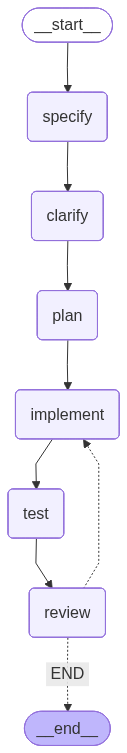

In [59]:
from IPython.display import Image, display
# Assuming 'app' is already compiled from previous steps
display(Image(sdd_app.get_graph().draw_mermaid_png()))

In [44]:
'''
result = sdd_app.invoke({
    "idea": "Home screen for displaying an e-commerce web page with iphones",
    "spec_md": "",
    "clarifications": [],
    "clarification_answers": [],
    "impl_plan_md": "",
    "tasks_md": "",
    "dev_tasks": [],
    "code_changes": {},
})

print("DEV TASKS:")
for t in result["dev_tasks"]:
    print("-", t)

print("\nCODE CHANGES (summaries):")
for task, summary in result["code_changes"].items():
    print(f"\n{task}\n{summary}\n")

    '''

DEV TASKS:
- DEV-1: Implement the "Featured iPhones" section displaying 3 models (links: US-1, FR-1)
- DEV-2: Develop the search bar functionality for iPhone models (links: US-2, FR-2)
- DEV-3: Create product detail pages for each featured iPhone model (links: US-3, FR-1)
- DEV-4: Ensure responsive layout for mobile, tablet, and desktop (links: US-4, FR-1)
- DEV-5: Implement error handling for no available products in "Featured iPhones" (links: US-1, FR-1)
- DEV-6: Develop search functionality with misspelling correction (links: US-2, FR-2)
- DEV-7: Optimize the home screen for loading speed under 2 seconds (links: US-1, FR-1)

CODE CHANGES (summaries):

DEV-1: Implement the "Featured iPhones" section displaying 3 models (links: US-1, FR-1)
To implement the task DEV-1, which involves creating the "Featured iPhones" section displaying 3 models, I'll focus on creating a single HTML file with embedded CSS. This section will include images, names, and prices for each iPhone model.

Here's 

In [67]:
pip show langgraph

Name: langgraph
Version: 1.1.4
Summary: Building stateful, multi-actor applications with LLMs
Home-page: https://docs.langchain.com/oss/python/langgraph/overview
Author: 
Author-email: 
License: 
Location: /usr/local/lib/python3.12/dist-packages
Requires: langchain-core, langgraph-checkpoint, langgraph-prebuilt, langgraph-sdk, pydantic, xxhash
Required-by: langchain


In [47]:
print (result)


{'idea': 'Home screen for displaying an e-commerce web page with iphones', 'spec_md': '# Specification for E-commerce Home Screen Displaying iPhones\n\n## 1. Overview\nThe purpose of this specification is to outline the requirements for the home screen of an e-commerce platform that primarily displays iPhones. The home screen will serve as the entry point for users accessing the website on various devices (mobile, tablet, desktop) and will include various features to enhance user experience and drive conversions.\n\n## 2. User Personas\n1. **Tech-savvy Shopper**: A user who is familiar with online shopping and seeks the latest iPhone models and accessories. They value detailed product information and user reviews.\n2. **Occasional Shopper**: A user who may not frequently shop online but is interested in purchasing an iPhone. They require an intuitive interface and straightforward navigation.\n3. **Gift Giver**: A user looking to buy an iPhone as a gift. They appreciate recommendations 

In [50]:
msgs = result

for i, m in enumerate(msgs, start=1):
    print(f"\n[{i}] role={getattr(m, 'role', type(m).__name__)}")
    print(f"name={m}")
    print(f"content={msgs[m]}")


[1] role=str
name=idea
content=Home screen for displaying an e-commerce web page with iphones

[2] role=str
name=spec_md
content=# Specification for E-commerce Home Screen Displaying iPhones

## 1. Overview
The purpose of this specification is to outline the requirements for the home screen of an e-commerce platform that primarily displays iPhones. The home screen will serve as the entry point for users accessing the website on various devices (mobile, tablet, desktop) and will include various features to enhance user experience and drive conversions.

## 2. User Personas
1. **Tech-savvy Shopper**: A user who is familiar with online shopping and seeks the latest iPhone models and accessories. They value detailed product information and user reviews.
2. **Occasional Shopper**: A user who may not frequently shop online but is interested in purchasing an iPhone. They require an intuitive interface and straightforward navigation.
3. **Gift Giver**: A user looking to buy an iPhone as a gif

In [77]:
'''
clarifications = [
    "1. What specific product categories (e.g., Electronics, Fashion, Home) should be included on the Home Screen, and are there any requirements for the order in which they are displayed?",
    "2. How frequently will the promotional banners be updated, and what criteria will be used to select the promotions that are displayed?",
    "3. Are there specific analytics or tracking requirements for user interactions on the Home Screen, such as which elements to track or how to measure user engagement?",
    "4. Are there any specific branding or design guidelines (e.g., color schemes, fonts, logo usage) that must be followed for the Home Screen layout to ensure consistency with the overall brand identity?",
    "5. What should be the fallback behavior if there are no featured products available—should the section be hidden entirely, or should it display a specific placeholder message?",
]
'''

In [78]:
'''
clarification_answers = [
    # 1. Categories + order
    "Include categories: Electronics, Fashion, Home & Kitchen, Beauty & Personal Care, Sports & Outdoors. Display in this order based on business priority: Electronics, Fashion, Home & Kitchen, Beauty, Sports.",

    # 2. Promo banner update rules
    "Update promotional banners weekly, or immediately when a major campaign launches. Prioritize campaigns by business priority, expected revenue uplift, and historical CTR. Retire banners with CTR below 1% after two weeks.",

    # 3. Analytics / tracking
    "Track clicks on: hero banner, each category card, each featured product card, and user account icon. Track page view, scroll depth (25/50/75/100%), and search usage from the header. Send events to Google Analytics GA4 with event names like 'home_hero_click', 'home_category_click', 'home_featured_click'.",

    # 4. Branding & design guidelines
    "Follow existing brand system: primary color #0052CC, secondary #FF6A00, neutral grays for backgrounds. Use the core brand font (e.g., Inter or Roboto) at 16px base size. Logo must appear left in the header with 16px padding, and CTAs should use the primary color with 4px border radius.",

    # 5. Fallback for no featured products
    "If there are no featured products, hide the product cards and show a placeholder tile with the text 'Featured picks are coming soon' plus a 'Browse all products' link to the main catalog. Do not show an empty section with only a heading.",
]
'''

In [79]:
'''
spec_md_lines = [
    "# Home Screen Specification for E-commerce Web Page",
    "",
    "## 1. Overview",
    "The Home Screen of the e-commerce web application serves as the primary entry point for users. It displays various product categories, promotional banners, featured products, and access to user account functionalities. The design must be responsive to provide a seamless experience across devices, including mobile, tablet, and desktop.",
    "",
    "## 2. User Personas",
    "- **Shoppers**: Users looking to browse and purchase products across various categories such as electronics, fashion, and home goods.",
    "- **Returning Customers**: Users who have previously purchased and are looking for new products or deals.",
    "- **New Customers**: First-time visitors who need guidance and motivation to explore the store.",
    "- **Mobile Users**: Users accessing the e-commerce platform via smartphones or tablets who require quick navigation and easy access to key features.",
    "",
    "## 3. User Stories",
    "",
    "### User Story 1: View Categories",
    "As a **Shopper**, I want to view product categories on the Home Screen so that I can easily navigate to the products I am interested in.",
    "",
    "**Acceptance Criteria:**",
    "```",
    "Given I am on the Home Screen,",
    "When I view the page,",
    "Then I should see a list of product categories (e.g. Electronics, Fashion, Home) displayed prominently.",
    "```",
    "",
    "### User Story 2: Access Promotions",
    "As a **Returning Customer**, I want to see promotional banners on the Home Screen so that I can find deals and discounts.",
    "",
    "**Acceptance Criteria:**",
    "```",
    "Given I am on the Home Screen,",
    "When I look for promotional content,",
    "Then I should see at least one promotional banner showcasing current deals with a clickable link.",
    "```",
    "",
    "### User Story 3: Browse Featured Products",
    "As a **New Customer**, I want to see featured products on the Home Screen so that I can discover popular items.",
    "",
    "**Acceptance Criteria:**",
    "```",
    "Given I am on the Home Screen,",
    "When I look for featured products,",
    "Then I should see a section displaying at least 5 featured products with images, names, and prices.",
    "```",
    "",
    "### User Story 4: Access User Account",
    "As a **Shopper**, I want to access my user account from the Home Screen so that I can view my order history and manage my profile.",
    "",
    "**Acceptance Criteria:**",
    "```",
    "Given I am on the Home Screen,",
    "When I look for user account options,",
    "Then I should see a user account icon or link that takes me to my account page.",
    "```",
    "",
    "## 4. Functional Requirements",
    "- The Home Screen must display a responsive layout that adjusts to different screen sizes (mobile, tablet, desktop).",
    "- The product categories must be clickable and redirect users to the respective category pages.",
    "- Promotional banners must be dynamically updated based on current campaigns.",
    "- Featured products must include at least an image, title, price, and link to the product page.",
    "- User account access must include options for login, registration, viewing order history, and managing personal information.",
    "",
    "## 5. Non-Functional Requirements",
    "- The Home Screen must load in under 3 seconds on standard broadband connections.",
    "- The design must adhere to accessibility standards (WCAG 2.1) to ensure usability for all customers, including those with disabilities.",
    "- The Home Screen must be optimized for SEO to ensure visibility in search engine results.",
    "",
    "## 6. Edge Cases & Constraints",
    "- If there are no featured products, the section should not be displayed or should include a placeholder message.",
    "- If a category has no products, the category link should still be present but lead to a dedicated \"No Products Available\" page.",
    "- The promotional banners should not exceed a maximum of 3 to avoid cluttering the Home Screen.",
    "",
    "## 7. Open Questions",
    "- What specific categories are to be included on the Home Screen?",
    "- How frequently will the promotional banners be updated, and what will be the criteria for selecting them?",
    "- Should there be any specific analytics or tracking requirements for user interactions on the Home Screen?",
    "- Are there any branding or design guidelines that need to be adhered to for the Home Screen layout?",
]
'''

In [80]:
#specdetails="\n".join(spec_md_lines)

In [84]:
#print (specdetails#)

# Home Screen Specification for E-commerce Web Page

## 1. Overview
The Home Screen of the e-commerce web application serves as the primary entry point for users. It displays various product categories, promotional banners, featured products, and access to user account functionalities. The design must be responsive to provide a seamless experience across devices, including mobile, tablet, and desktop.

## 2. User Personas
- **Shoppers**: Users looking to browse and purchase products across various categories such as electronics, fashion, and home goods.
- **Returning Customers**: Users who have previously purchased and are looking for new products or deals.
- **New Customers**: First-time visitors who need guidance and motivation to explore the store.
- **Mobile Users**: Users accessing the e-commerce platform via smartphones or tablets who require quick navigation and easy access to key features.

## 3. User Stories

### User Story 1: View Categories
As a **Shopper**, I want to view p

In [88]:
'''
result = sdd_app.invoke({
    "idea": "Home screen for displaying an e-commerce web page for Cofee products",
    "spec_md": "",
    "clarifications": [],#clarifications,
    "clarification_answers":[], #clarification_answers,
    "impl_plan_md": "",
    "tasks_md": "",
    "dev_tasks": [],
    "code_changes": {},
})

print("DEV TASKS:")
for t in result["dev_tasks"]:
    print("- ", t)

print("\nCODE CHANGES (summaries):")
for task, summary in result["code_changes"].items():
    print(f"\n{task}\n{summary}\n")
    '''

'\nresult = sdd_app.invoke({\n    "idea": "Home screen for displaying an e-commerce web page for Cofee products",\n    "spec_md": "",\n    "clarifications": [],#clarifications,\n    "clarification_answers":[], #clarification_answers,\n    "impl_plan_md": "",\n    "tasks_md": "",\n    "dev_tasks": [],\n    "code_changes": {},\n})\n\nprint("DEV TASKS:")\nfor t in result["dev_tasks"]:\n    print("- ", t)\n\nprint("\nCODE CHANGES (summaries):")\nfor task, summary in result["code_changes"].items():\n    print(f"\n{task}\n{summary}\n")\n    '

In [ ]:
msgs = result

for i, m in enumerate(msgs, start=1):
    print(f"\n[{i}] role={getattr(m, 'role', type(m).__name__)}")
    print(f"name={m}")
    print(f"content={msgs[m]}")

other output!!

In [56]:

msgs = result

for i, m in enumerate(msgs, start=1):
    print(f"\n[{i}] role={getattr(m, 'role', type(m).__name__)}")
    print(f"name={m}")
    print(f"content={msgs[m]}")



[1] role=str
name=idea
content=Home screen for displaying an e-commerce web page for Balusoft.AI

[2] role=str
name=spec_md
content=# Specification for Balusoft.AI Home Screen

## 1. Overview
The Balusoft.AI Home Screen will serve as the primary interface for a multi-category e-commerce web application. The design will accommodate various product categories, including electronics, fashion, and home goods, and will be optimized for responsive display across mobile, tablet, and desktop devices. The objective is to create an intuitive and engaging user experience that encourages exploration and purchase.

## 2. User Personas
1. **Tech-Savvy Shopper**
   - Age: 25-35
   - Comfortable using technology and online shopping.
   - Prefers quick access to deals and new arrivals.

2. **Casual Browser**
   - Age: 18-24
   - Occasionally shops online, looking for inspiration.
   - Enjoys exploring various categories without a specific intention to buy.

3. **Family Shopper**
   - Age: 35-50
   - S

In [65]:
from langchain_openai import ChatOpenAI
from langchain_core.messages import SystemMessage, HumanMessage

# Using the same model as in test_node
llm_test_diag = ChatOpenAI(model="gpt-4o", temperature=0)

system_msg_content_diag = "You are a helpful assistant."
user_msg_content_diag = "Tell me a short, funny joke."

messages_diag = [
    SystemMessage(content=system_msg_content_diag),
    HumanMessage(content=user_msg_content_diag),
]

try:
    print("\n--- Attempting direct LLM call ---")
    response_diag = llm_test_diag.invoke(messages_diag)
    print("Diagnostic LLM call successful. Response:")
    print(response_diag.content)
    print("--- Direct LLM call finished ---")
except Exception as e:
    print(f"Diagnostic LLM call failed with error: {e!r}")
    print("--- Direct LLM call finished ---")


--- Attempting direct LLM call ---
Diagnostic LLM call successful. Response:
Why don't skeletons fight each other? They don't have the guts!
--- Direct LLM call finished ---
